In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.ToTensor()
train_data = datasets.FashionMNIST(root="./data",train=True,download=True,transform=transform)
test_data = datasets.FashionMNIST(root="./data",train=False,download=True,transform=transform)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.1MB/s]


In [ ]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
train = DataLoader(train_data, batch_size=32)
test = DataLoader(test_data, batch_size=32)

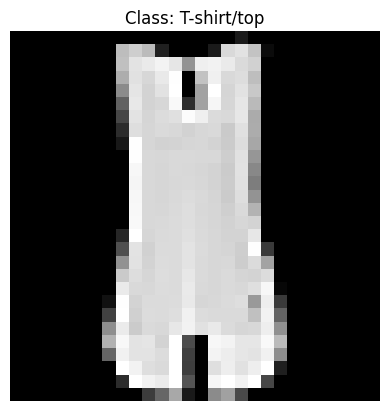

In [ ]:
words = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

images, labels = next(iter(train))
idx = 4

plt.imshow(images[idx].squeeze(), cmap='gray')
plt.title(f'Class: {words[labels[idx].item()]}')
plt.axis('off')
plt.show()

In [ ]:
class CheckImage(nn.Module):
    def __init__(self):
        super().__init__()

        self.first = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.second = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 10)
        )

    def forward(self, i):
        i = self.first(i)
        i = self.second(i)
        return i

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available else 'cpu')


In [ ]:
device

device(type='cuda')

In [ ]:
model = CheckImage().to(device)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
for epoch in range(10):
  model.train()
  total_loss = 0

  for x_batch, y_batch in train:
      x_batch, y_batch = x_batch.to(device), y_batch.to(device)

      y_pred = model(x_batch)
      loss = loss_fn(y_pred, y_batch)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      total_loss +- loss.item()

  print(f'Эпоха {epoch + 1}, потери {round(total_loss, 2)}')

Эпоха 1, потери 0
Эпоха 2, потери 0
Эпоха 3, потери 0
Эпоха 4, потери 0
Эпоха 5, потери 0
Эпоха 6, потери 0
Эпоха 7, потери 0
Эпоха 8, потери 0
Эпоха 9, потери 0
Эпоха 10, потери 0


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in test:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        y_pred = model(x_batch)
        predicted = torch.argmax(y_pred, dim=1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
print(f'Точность модели на тестовых данных: {round(accuracy, 2)}%')


Точность модели на тестовых данных: 91.51%


In [ ]:
torch.save(model.state_dict(), 'model.pth')